## Multiple LSTMs - IMDB dataset

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import keras_nlp

### Load and prepare dataset

In [2]:
imdb = tfds.load("imdb_reviews", as_supervised=True, data_dir="./Data/", download=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling Data/imdb_reviews/plain_text/incomplete.SMS3BH_1.0.0/imdb_reviews-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling Data/imdb_reviews/plain_text/incomplete.SMS3BH_1.0.0/imdb_reviews-test.tfrecord*...:   0%|          …

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling Data/imdb_reviews/plain_text/incomplete.SMS3BH_1.0.0/imdb_reviews-unsupervised.tfrecord*...:   0%|  …

Dataset imdb_reviews downloaded and prepared to Data/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [3]:
train_reviews = imdb['train'].map(lambda review,label: review)
train_labels = imdb['train'].map(lambda review,label: label)

test_reviews = imdb['test'].map(lambda review,label: review)
test_labels = imdb['test'].map(lambda review,label: label)

In [4]:
for review in imdb['train'].take(1):
    print(review)

(<tf.Tensor: shape=(), dtype=string, numpy=b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.">, <tf.Tensor: shape=(), dtype=int64, numpy=0>)


In [5]:
# Tokenizer

subword_tokenizer = keras_nlp.tokenizers.WordPieceTokenizer(
    vocabulary="./Data/imdb_vocab_subwords.txt"
)

In [6]:
# Data pipeline and padding parameters
SHUFFLE_BUFFER_SIZE = 10000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE
BATCH_SIZE = 256
PADDING_TYPE = 'pre'
TRUNC_TYPE = 'post'

In [7]:
def padding_func(sequences):

    sequences = sequences.ragged_batch(batch_size=sequences.cardinality())
    sequences = sequences.get_single_element()

    padded_sequences = tf.keras.utils.pad_sequences(sequences.numpy(),
                                                   truncating=TRUNC_TYPE,
                                                   padding=PADDING_TYPE)
    padded_sequences = tf.data.Dataset.from_tensor_slices(padded_sequences)
    return padded_sequences

In [8]:
# Generate integer sequences using the subword tokenizer
train_sequences_subword = train_reviews.map(lambda review: subword_tokenizer.tokenize(review)).apply(padding_func)
test_sequences_subword = test_reviews.map(lambda review: subword_tokenizer.tokenize(review)).apply(padding_func)

# Combine integer sequences and labels
train_dataset_vectorized = tf.data.Dataset.zip(train_sequences_subword, train_labels)
test_dataset_vectorized = tf.data.Dataset.zip(test_sequences_subword, test_labels)

# Optimize the datasets for training
train_dataset_final = (train_dataset_vectorized
                       .shuffle(SHUFFLE_BUFFER_SIZE)
                       .cache()
                       .prefetch(buffer_size=PREFETCH_BUFFER_SIZE)
                       .batch(BATCH_SIZE))

test_dataset_final = (test_dataset_vectorized
                      .cache()
                      .prefetch(buffer_size=PREFETCH_BUFFER_SIZE)
                      .batch(BATCH_SIZE))

In [9]:
for processed_element in train_dataset_final.take(1):
    print(processed_element[0])


tf.Tensor(
[[   0    0    0 ... 1324  171   15]
 [   0    0    0 ... 2758  361   15]
 [   0    0    0 ... 1909 5181   15]
 ...
 [   0    0    0 ...   84 6951   15]
 [   0    0    0 ...  415  860  275]
 [   0    0    0 ... 1869 1864   15]], shape=(256, 4008), dtype=int32)


### Build and compile model

<br>

You can build multiple layer LSTM models by simply appending another `LSTM` layer in your `Sequential` model and enabling the `return_sequences` flag to `True`. This is because an `LSTM` layer expects a sequence input so if the previous layer is also an LSTM, then it should output a sequence as well. See the code cell below that demonstrates this flag in action.<br><br> You'll notice that the output dimension is in 3 dimensions `(batch_size, timesteps, features)` when `return_sequences` is True.

##### How does LSTM with `return_sequences=True` work ?

In [10]:
# Parameters
BATCH_SIZE = 1
TIMESTEPS = 20
FEATURES = 16
LSTM_DIM = 8

print(f'batch_size: {BATCH_SIZE}')
print(f'timesteps (sequence length): {TIMESTEPS}')
print(f'features (embedding size): {FEATURES}')
print(f'lstm output units: {LSTM_DIM}')

# Define array input with random values
random_input = np.random.rand(BATCH_SIZE,TIMESTEPS,FEATURES)
print(f'shape of input array: {random_input.shape}')

# Define LSTM that returns a single output
lstm = tf.keras.layers.LSTM(LSTM_DIM)
result = lstm(random_input)
print(f'shape of lstm output(return_sequences=False): {result.shape}')

# Define LSTM that returns a sequence
lstm_rs = tf.keras.layers.LSTM(LSTM_DIM, return_sequences=True)
result = lstm_rs(random_input)
print(f'shape of lstm output(return_sequences=True): {result.shape}')

batch_size: 1
timesteps (sequence length): 20
features (embedding size): 16
lstm output units: 8
shape of input array: (1, 20, 16)
shape of lstm output(return_sequences=False): (1, 8)
shape of lstm output(return_sequences=True): (1, 20, 8)


In [11]:
# Model parameters
embedding_dim = 64
lstm1_dim = 32
lstm2_dim = 16
dense_dim = 64

model = tf.keras.Sequential([
    tf.keras.Input(shape=(None,)),
    tf.keras.layers.Embedding(subword_tokenizer.vocabulary_size(), embedding_dim),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(lstm1_dim, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(lstm2_dim)),
    tf.keras.layers.Dense(dense_dim, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │       488,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 64)       │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 526,017 (2.01 MB)

 Trainable params: 526,017 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [13]:
NUM_EPOCHS = 5

# Train the model
history = model.fit(train_dataset_final, epochs=NUM_EPOCHS, validation_data=test_dataset_final)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 85s 808ms/step - accuracy: 0.6083 - loss: 0.6264 - val_accuracy: 0.8426 - val_loss: 0.3648
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 79s 804ms/step - accuracy: 0.8706 - loss: 0.3122 - val_accuracy: 0.8481 - val_loss: 0.3588
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 78s 800ms/step - accuracy: 0.8974 - loss: 0.2547 - val_accuracy: 0.8044 - val_loss: 0.4242
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 78s 803ms/step - accuracy: 0.8987 - loss: 0.2485 - val_accuracy: 0.8428 - val_loss: 0.3866
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 78s 802ms/step - accuracy: 0.9333 - loss: 0.1776 - val_accuracy: 0.8354 - val_loss: 0.3930


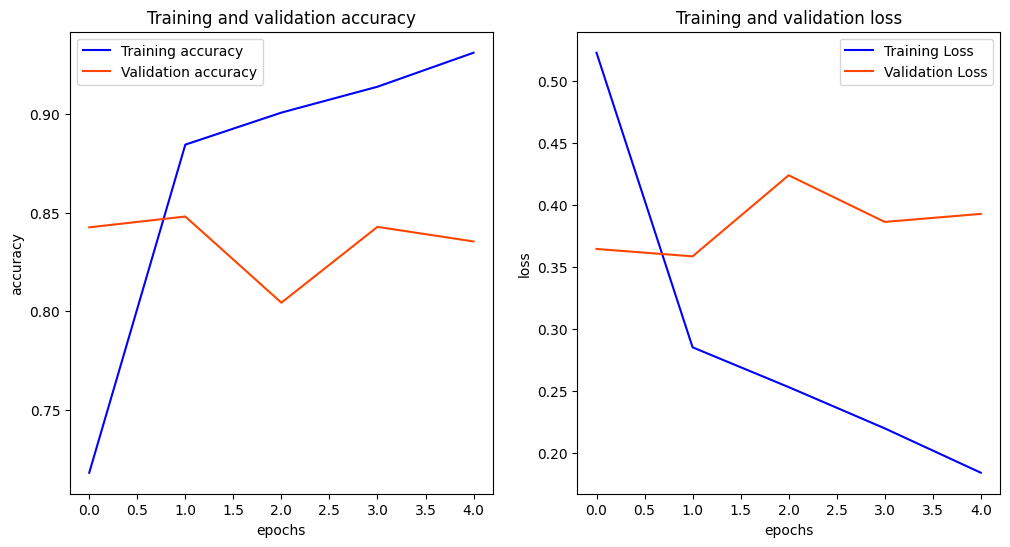

In [18]:
def plot_loss_acc(history):

    '''Plots the training and validation loss and accuracy from a history object'''
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    fig, ax = plt.subplots(1,2, figsize=(12, 6))
    ax[0].plot(epochs, acc, label='Training accuracy', color="blue")
    ax[0].plot(epochs, val_acc, label='Validation accuracy', color="orangered")
    ax[0].set_title('Training and validation accuracy')
    ax[0].set_xlabel('epochs')
    ax[0].set_ylabel('accuracy')
    ax[0].legend()

    ax[1].plot(epochs, loss, label='Training Loss', color="blue")
    ax[1].plot(epochs, val_loss, label='Validation Loss', color="orangered")
    ax[1].set_title('Training and validation loss')
    ax[1].set_xlabel('epochs')
    ax[1].set_ylabel('loss')
    ax[1].legend()

    plt.show()
plot_loss_acc(history)